In [145]:
import sys
print(f"Success! Using Environment: {sys.prefix}")

Success! Using Environment: /home/sagemaker-user/Language-Translation/mnit_env


In [146]:
!nvidia-smi

Sat Mar 28 18:43:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   29C    P0             26W /   70W |     783MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [147]:
import torch
import pickle
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


import os
import re
import shutil
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gc
import gensim.downloader as api
from collections import Counter

In [148]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [149]:
import dagshub
import mlflow
dagshub.init(repo_owner='thanwal', repo_name='Language-Translation', mlflow=True)

Initialized MLflow to track repo "thanwal/Language-Translation"

Repository thanwal/Language-Translation initialized!

Load Dataset from drive or upload to drive re-run

In [150]:
df = pd.read_csv('data/Sentence_pairs_max_5_tokens.csv')
print(df.head())

              English            Hindi
0  That won't happen.  वैसा नहीं होगा।
1       Are you sure?           पक्का?
2           Hurry up.       जल्दी करो!
3      You can do it.  तुम कर सकते हो।
4      You can do it.  तुम कर सकती हो।


In [151]:
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

special_tokens = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']
MIN_FREQ = 2
embedding_dim = 300

Function to create English embeddings

In [152]:
def create_English_embedding(df):
    English_train = df['English']
    English_word2vec = api.load('word2vec-google-news-300')

    English_train_sentences = [tokenize(x) for x in English_train]
    print(len(English_train_sentences))

    English_counter = Counter()
    for s in English_train_sentences:
        English_counter.update(s)

    English_valid_words = [w for w, count in English_counter.most_common() if count >= MIN_FREQ]

    English_word2idx = {tok: idx for idx, tok in enumerate(special_tokens)}
    for word in English_valid_words:
        English_word2idx[word] = len(English_word2idx)

    English_idx2word = {idx: word for word, idx in English_word2idx.items()}

    English_embedding_matrix = [np.zeros(embedding_dim), 
                                np.random.normal(scale=0.6, size=(embedding_dim,)),
                                np.zeros(embedding_dim),
                                np.zeros(embedding_dim)]

    for word in English_valid_words:
        if word in English_word2vec:
            English_embedding_matrix.append(English_word2vec[word])
        else:
            English_embedding_matrix.append(np.random.normal(scale=0.6, size=(embedding_dim,)))

    English_embedding_matrix = torch.from_numpy(np.array(English_embedding_matrix)).float()

    if len(English_embedding_matrix) == len(English_word2idx) == len(English_idx2word):
        print(len(English_word2idx))
        print(English_embedding_matrix.shape)

    del English_word2vec 
    gc.collect()

    return English_embedding_matrix, English_word2idx, English_idx2word

Function to create Hindi embeddings

In [153]:
def create_Hindi_embedding(df):
    Hindi_train = df['Hindi']
    Hindi_word2vec = api.load('fasttext-wiki-news-subwords-300')
    
    Hindi_train_sentences = [tokenize(x) for x in Hindi_train]
    print(len(Hindi_train_sentences))

    Hindi_counter = Counter()

    for s in Hindi_train_sentences:
        Hindi_counter.update(s)

    Hindi_valid_words = [w for w, count in Hindi_counter.most_common() if count >= MIN_FREQ]

    Hindi_word2idx={tok: idx for idx, tok in enumerate(special_tokens)}
    for word in Hindi_valid_words:
        Hindi_word2idx[word] = len(Hindi_word2idx)

    Hindi_idx2word = {idx: word for word, idx in Hindi_word2idx.items()}

    Hindi_embedding_matrix = [np.zeros(embedding_dim),
                            np.random.normal(scale=0.6, size=(embedding_dim,)),
                            np.zeros(embedding_dim),
                            np.zeros(embedding_dim)]

    for word in Hindi_valid_words:
        if word in Hindi_word2vec:
            Hindi_embedding_matrix.append(Hindi_word2vec[word])
        else:
            Hindi_embedding_matrix.append(np.random.normal(scale=0.6, size=(embedding_dim,)))

    Hindi_embedding_matrix = torch.from_numpy(np.array(Hindi_embedding_matrix)).float()

    if len(Hindi_embedding_matrix)==len(Hindi_word2idx)==len(Hindi_idx2word):
        print(len(Hindi_word2idx))
        print(Hindi_embedding_matrix.shape)

    del Hindi_word2vec 
    gc.collect()

    return Hindi_embedding_matrix, Hindi_word2idx, Hindi_idx2word

Load saved Ebedding or create and save for re-run to drive 

In [154]:
saves_path = 'saves'
if os.path.exists(saves_path):
    English_embedding_matrix = torch.load(os.path.join(saves_path, 'eng_emb.pt'))
    Hindi_embedding_matrix = torch.load(os.path.join(saves_path, 'hin_emb.pt'))

    with open(os.path.join(saves_path, 'eng_word2idx.pkl'), 'rb') as f:
        English_word2idx = pickle.load(f)

    with open(os.path.join(saves_path, 'hin_word2idx.pkl'), 'rb') as f:
        Hindi_word2idx = pickle.load(f)

    with open(os.path.join(saves_path, 'eng_idx2word.pkl'), 'rb') as f:
        English_idx2word = pickle.load(f)

    with open(os.path.join(saves_path, 'hin_idx2word.pkl'), 'rb') as f:
        Hindi_idx2word = pickle.load(f)

    print("All files loaded successfully from local directory.")

else:
    # Creation logic (assuming df and creation functions are defined elsewhere)
    English_embedding_matrix, English_word2idx, English_idx2word = create_English_embedding(df)
    Hindi_embedding_matrix, Hindi_word2idx, Hindi_idx2word = create_Hindi_embedding(df)

    # Create the folder locally if it doesn't exist
    os.makedirs(saves_path, exist_ok=True)

    # Saving logic
    torch.save(English_embedding_matrix, os.path.join(saves_path, 'eng_emb.pt'))
    torch.save(Hindi_embedding_matrix, os.path.join(saves_path, 'hin_emb.pt'))

    with open(os.path.join(saves_path, 'eng_word2idx.pkl'), 'wb') as f:
        pickle.dump(English_word2idx, f)

    with open(os.path.join(saves_path, 'hin_word2idx.pkl'), 'wb') as f:
        pickle.dump(Hindi_word2idx, f)

    with open(os.path.join(saves_path, 'eng_idx2word.pkl'), 'wb') as f:
        pickle.dump(English_idx2word, f)

    with open(os.path.join(saves_path, 'hin_idx2word.pkl'), 'wb') as f:
        pickle.dump(Hindi_idx2word, f)

    print(f"All files saved successfully to: {os.path.abspath(saves_path)}")

All files loaded successfully from local directory.


/tmp/ipykernel_2078/3156688585.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  English_embedding_matrix = torch.load(os.path.join(saves_path, 'eng_emb.pt'))
/tmp/ipykern

Split data into Train, Test, Val

In [155]:
df_train_val, df_test = train_test_split(df, test_size=0.10, random_state=42)
df_train, df_val = train_test_split(df_train_val, test_size=0.2, random_state=42)

finding max lenght for data sample

99% of English sentences are shorter than: 5.0
99% of Hindi sentences are shorter than: 5.0


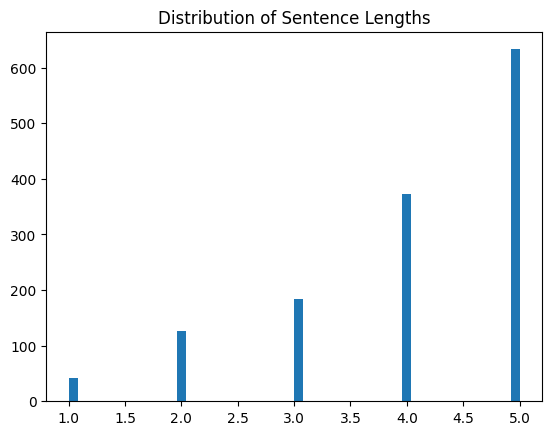

Max Len is 7.0


In [156]:
English_train = df_train['English']
English_train = df_train['Hindi']

eng_lengths = [len(tokenize(s)) for s in English_train]
hin_lengths = [len(tokenize(s)) for s in English_train]


max_len=max(np.percentile(eng_lengths, 99),np.percentile(hin_lengths, 99))+2

print(f"99% of English sentences are shorter than: {np.percentile(eng_lengths, 99)}")
print(f"99% of Hindi sentences are shorter than: {np.percentile(hin_lengths, 99)}")

plt.hist(eng_lengths, bins=50)
plt.title("Distribution of Sentence Lengths")
plt.show()

print(f"Max Len is {max_len}")

Create custom dataset

In [157]:
class TranslationDataset(Dataset):
    def __init__(self, df, English_word2idx, Hindi_word2idx, max_len=20):
        self.df = df
        self.English_word2idx = English_word2idx
        self.Hind_word2idx = Hindi_word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def preprocess(self, text, word2idx):
        tokens = tokenize(text)
        indices = [word2idx.get(tok, 1) for tok in tokens]
        indices = [2] + indices + [3]

        if len(indices) < self.max_len:
            indices += [0] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        return torch.tensor(indices, dtype=torch.long)

    def __getitem__(self, idx):
        english_text = self.df.iloc[idx]['English']
        hindi_text = self.df.iloc[idx]['Hindi']

        English_tensor = self.preprocess(english_text, self.English_word2idx)
        Hindi_tensor = self.preprocess(hindi_text, self.Hind_word2idx)

        return English_tensor, Hindi_tensor

Loading data into DataLoaders

In [158]:
BATCH_SIZE=1024

train_dataset = TranslationDataset(df_train, English_word2idx, Hindi_word2idx, max_len=7)
val_dataset = TranslationDataset(df_val, English_word2idx, Hindi_word2idx, max_len=7)
test_dataset = TranslationDataset(df_test, English_word2idx, Hindi_word2idx, max_len=7)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Varifying that DataLoader and Custom dataset is working fine

In [159]:
English_batch, Hindi_batch = next(iter(train_loader))

print(f"English Batch Shape: {English_batch.shape}")
print(f"Hindi Batch Shape: {Hindi_batch.shape}")

first_sentence = English_batch[0].tolist()
decoded = [English_idx2word.get(idx, '<UNK>') for idx in first_sentence]
print("\nFirst English Sentence in Batch:")
print(" ".join(decoded))

English Batch Shape: torch.Size([1024, 7])
Hindi Batch Shape: torch.Size([1024, 7])

First English Sentence in Batch:
<SOS> that wasn t the reason <EOS>


Encoder Unit

In [160]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, pretrained_embeddings):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.dropout= nn.Dropout(dropout)

    def forward(self, English_batch):
        embedded = self.dropout(self.embedding(English_batch))
        outputs, hidden = self.rnn(embedded)

        return hidden

Decoder

In [161]:
class Decoder(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, num_layers, dropout, pretrained_embeddings):
        super().__init__()

        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden):
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(1))

        return prediction, hidden

Seq2Seq Model

In [162]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        
        self.encoder = encoder 
        self.decoder = decoder
        self.device = device

    def forward(self, English_batch, Hindi_batch, tfr=0.5):
        batch_size = English_batch.shape[0]
        Hindi_len = Hindi_batch.shape[1]
        Hindi_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, Hindi_len, Hindi_vocab_size).to(self.device)
        hidden = self.encoder(English_batch)
        input = Hindi_batch[:, 0]

        for t in range(1, Hindi_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t, :] = output
            
            teacher_force = random.random() < tfr
            top_1 = output.argmax(1) 
            input = Hindi_batch[:, t] if teacher_force else top_1

        return outputs

In [163]:
def calculate_accuracy(preds, y, pad_idx):
    top_preds = preds.argmax(1, keepdim=True).squeeze(1)
    
    correct = top_preds.eq(y)
    
    mask = (y != pad_idx)
    correct = correct & mask
    
    accuracy = correct.sum().float() / mask.sum().float()
    return accuracy

In [164]:
def evaluate(model, val_loader, criterion):
    model.eval() 
    epoch_loss = 0
    epoch_acc = 0
    
    with torch.no_grad(): 
        for English_batch, Hindi_batch in val_loader:
            English_batch, Hindi_batch = English_batch.to(device), Hindi_batch.to(device)
            
            output = model(English_batch, Hindi_batch, 0) 
            
            output_dim = output.shape[-1]
            output = output[:, 1:, :].reshape(-1, output_dim)
            Hindi_batch = Hindi_batch[:, 1:].reshape(-1)
            
            loss = criterion(output, Hindi_batch)
            acc = calculate_accuracy(output, Hindi_batch, 0)
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            
    return epoch_loss / len(val_loader), epoch_acc / len(val_loader)

Traning Loop

In [165]:
import torch

clip = 1
epoches = 50
hidden_dim = 512
num_layers = 2
dropout = 0.4
lr = 0.001
Hindi_vocab_size = len(Hindi_word2idx) 

encoder = Encoder(embedding_dim, hidden_dim, num_layers, dropout, English_embedding_matrix).to(device)
decoder = Decoder(embedding_dim, Hindi_vocab_size, hidden_dim, num_layers, dropout, Hindi_embedding_matrix).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

optimizer = optim.Adam(model.parameters(), lr)
criterion = nn.CrossEntropyLoss(ignore_index=0)

# 3. Start MLflow Run
mlflow.set_experiment("Language_Translation_RNN_base")
with mlflow.start_run(run_name="only_RNN_run_last"):
    
    # Log hyperparameters
    mlflow.log_params({
        "epochs": epoches,
        "hidden_dim": hidden_dim,
        "num_layers": num_layers,
        "dropout": dropout,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": lr
    })

    # Optional: Reset memory stats before starting
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(epoches):
        model.train()
        epoch_loss = 0.0
        epoch_acc = 0.0

        for English_batch, Hindi_batch in train_loader:
            English_batch, Hindi_batch = English_batch.to(device), Hindi_batch.to(device)

            optimizer.zero_grad()
            output = model(English_batch, Hindi_batch)

            output_dim = output.shape[-1]
            output = output[:, 1:, :].reshape(-1, output_dim)
            Hindi_batch = Hindi_batch[:, 1:].reshape(-1)

            loss = criterion(output, Hindi_batch)
            acc = calculate_accuracy(output, Hindi_batch, 0)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

        train_loss = epoch_loss / len(train_loader)
        train_acc = epoch_acc / len(train_loader)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        # --- NEW: GPU Memory Tracking ---
        gpu_allocated_gb = 0.0
        gpu_peak_gb = 0.0
        if torch.cuda.is_available():
            # Current memory actively holding tensors
            gpu_allocated_gb = torch.cuda.memory_allocated(device) / (1024**3)
            # The highest spike in memory during this epoch (usually during backprop)
            gpu_peak_gb = torch.cuda.max_memory_allocated(device) / (1024**3)
            # Reset peak stats for the next epoch so it's accurate per-epoch
            torch.cuda.reset_peak_memory_stats(device)
        # --------------------------------

        # Log metrics to DagsHub MLflow per epoch (Added GPU stats)
        mlflow.log_metrics({
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "gpu_allocated_gb": gpu_allocated_gb, # Log to MLflow!
            "gpu_peak_gb": gpu_peak_gb            # Log to MLflow!
        }, step=epoch)

        # Updated print statement
        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"GPU Peak: {gpu_peak_gb:.2f}GB")

    with open("model_architecture.txt", "w") as f:
        f.write(str(model))
    mlflow.log_artifact("model_architecture.txt")
    
    # 2. Save the fully trained PyTorch model to DagsHub
    mlflow.pytorch.log_model(model, "pytorch_model")

Epoch 01 | Train Loss: 6.6849 | Train Acc: 0.1133 | Val Loss: 5.9797 | Val Acc: 0.2382 | GPU Peak: 0.33GB
Epoch 02 | Train Loss: 5.4150 | Train Acc: 0.2244 | Val Loss: 4.4988 | Val Acc: 0.2382 | GPU Peak: 0.35GB
Epoch 03 | Train Loss: 4.3229 | Train Acc: 0.2282 | Val Loss: 4.0123 | Val Acc: 0.1218 | GPU Peak: 0.35GB
Epoch 04 | Train Loss: 3.9528 | Train Acc: 0.1328 | Val Loss: 3.8723 | Val Acc: 0.2496 | GPU Peak: 0.35GB
Epoch 05 | Train Loss: 3.8005 | Train Acc: 0.2390 | Val Loss: 3.7647 | Val Acc: 0.2496 | GPU Peak: 0.35GB
Epoch 06 | Train Loss: 3.6902 | Train Acc: 0.2380 | Val Loss: 3.7204 | Val Acc: 0.2496 | GPU Peak: 0.35GB
Epoch 07 | Train Loss: 3.6790 | Train Acc: 0.2279 | Val Loss: 3.6947 | Val Acc: 0.2358 | GPU Peak: 0.35GB
Epoch 08 | Train Loss: 3.5823 | Train Acc: 0.2312 | Val Loss: 3.6892 | Val Acc: 0.2496 | GPU Peak: 0.35GB
Epoch 09 | Train Loss: 3.5494 | Train Acc: 0.2398 | Val Loss: 3.6836 | Val Acc: 0.2496 | GPU Peak: 0.35GB
Epoch 10 | Train Loss: 3.5705 | Train Acc: 0.2

2026/03/28 18:44:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 18:44:12 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/28 18:44:12 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/28 18:44:16 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). ML

🏃 View run only_RNN_run_last at: https://dagshub.com/thanwal/Language-Translation.mlflow/#/experiments/1/runs/f10525dffc144b23ad6a0b499662710a
🧪 View experiment at: https://dagshub.com/thanwal/Language-Translation.mlflow/#/experiments/1


In [166]:
def translate_sentence(sentence, model, English_word2idx, Hindi_idx2word, device, max_len=30):
    model.eval() 
    
    if isinstance(sentence, str):
        tokens = tokenize(sentence.lower())
    else:
        tokens = [word.lower() for word in sentence]
        
    indices = [English_word2idx.get(tok, 1) for tok in tokens] 
    indices = [2] + indices + [3] 
    
    English_tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        hidden = model.encoder(English_tensor)
        
    Hindi_indexes = [2] 
    
    for i in range(max_len):
        trg_tensor = torch.tensor([Hindi_indexes[-1]], dtype=torch.long).to(device)
        
        with torch.no_grad():
            output, hidden = model.decoder(trg_tensor, hidden)
            
        pred_token = output.argmax(1).item()
        Hindi_indexes.append(pred_token)
        
        if pred_token == 3:
            break
            
    trg_tokens = [Hindi_idx2word.get(i, '<UNK>') for i in Hindi_indexes]
    
    return " ".join(trg_tokens[1:-1])

In [167]:
test_indices = random.sample(range(len(df_test)), 10)

for idx in test_indices:
    src_sentence = df_test.iloc[idx]['English']
    true_translation = df_test.iloc[idx]['Hindi']
    
    model_prediction = translate_sentence(
        src_sentence, model, English_word2idx, Hindi_idx2word, device
    )
    
    print(f"English: {src_sentence}")
    print(f"Actual : {true_translation}")
    print(f"Model  : {model_prediction}")
    print("-" * 50)

English: I'm like you.
Actual : मैं आपके जैसा हूँ।
Model  : म म
--------------------------------------------------
English: Got it?
Actual : समझे कि नहीं?
Model  : म म
--------------------------------------------------
English: Hush!
Actual : चुप!
Model  : म म
--------------------------------------------------
English: Hello?
Actual : हैलो?
Model  : म म
--------------------------------------------------
English: I won!
Actual : मैं जीत गया!
Model  : म म
--------------------------------------------------
English: They're wrong.
Actual : वे गलत हैं।
Model  : म म
--------------------------------------------------
English: They're quiet.
Actual : वे शांत हैं।
Model  : म म
--------------------------------------------------
English: Quick!
Actual : जल्दी!
Model  : म म
--------------------------------------------------
English: I do not understand.
Actual : मैं समझा नहीं।
Model  : म म
--------------------------------------------------
English: Who is Tom?
Actual : टॉम कौन है?
Model  : म म
---